In [3]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [4]:
web_traffic = pd.read_csv("../data/web_traffic.csv")
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
order_item = pd.read_csv("../data/order_items.csv")
shipments = pd.read_csv("../data/shipments.csv")
reviews = pd.read_csv("../data/reviews.csv")
promotions = pd.read_csv("../data/promotions.csv")
sales = pd.read_csv("../data/sales.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20052\4042407951.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_item = pd.read_csv("../data/order_items.csv")


In [5]:
# Get count as a DataFrame
orders_per_date = orders.groupby('order_date').size().reset_index(name='order_count')

# Sort by date
orders_per_date = orders_per_date.sort_values('order_date')

# Basic stats
print(f"Average orders per day: {orders_per_date['order_count'].mean():.2f}")
print(f"Max orders on a day: {orders_per_date['order_count'].max()}")
print(f"Min orders on a day: {orders_per_date['order_count'].min()}")

Average orders per day: 168.78
Max orders on a day: 803
Min orders on a day: 8


In [9]:
orders_per_date.head(10)

,order_date,order_count
0,2012-07-04,162
1,2012-07-05,97
2,2012-07-06,93
3,2012-07-07,73
4,2012-07-08,88
5,2012-07-09,137
6,2012-07-10,183
7,2012-07-11,221
8,2012-07-12,246
9,2012-07-13,201


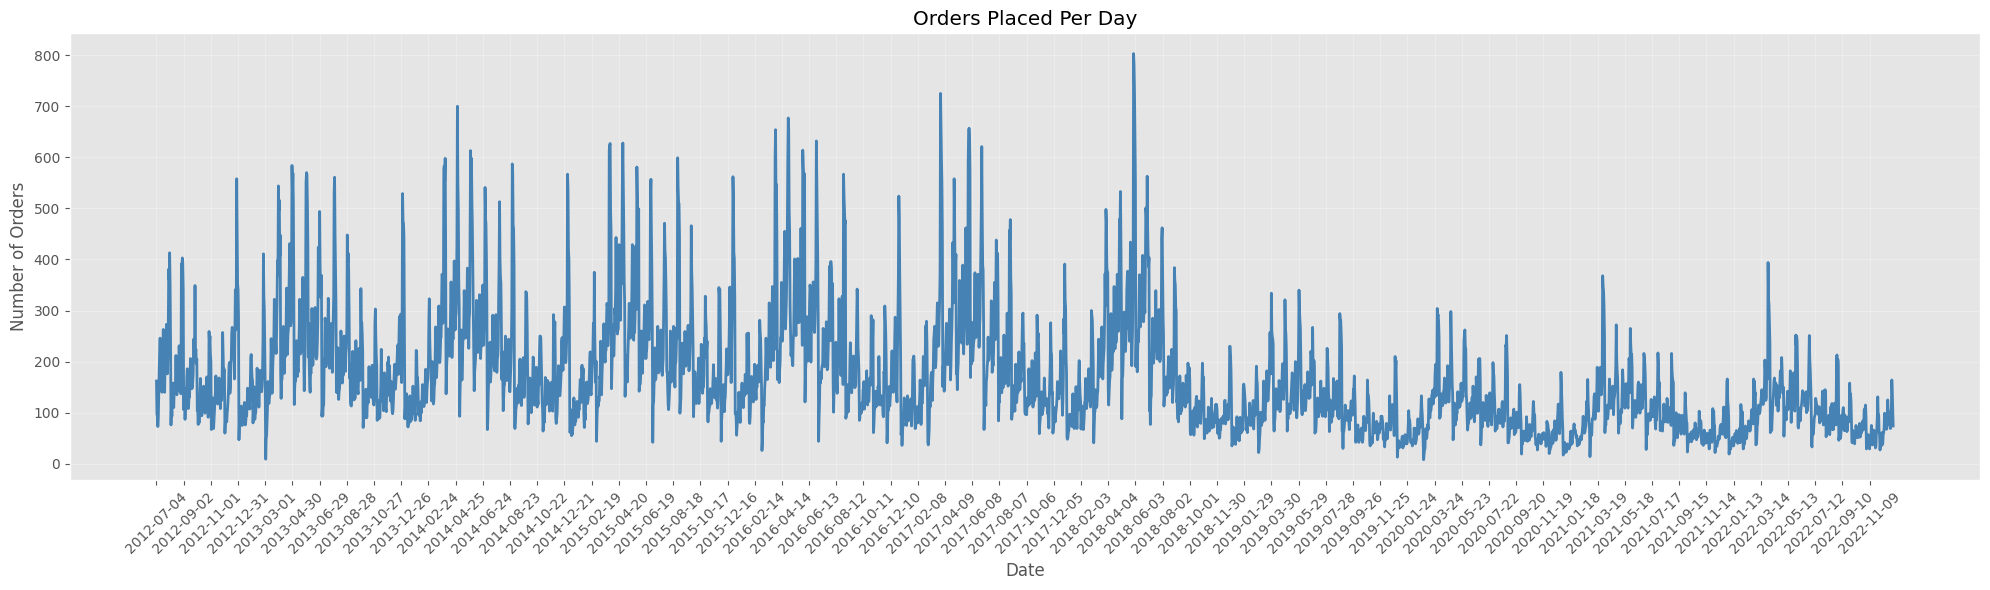

In [13]:
plt.figure(figsize=(20, 6))
plt.plot(orders_per_date['order_date'], orders_per_date['order_count'], linewidth=2, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Orders Placed Per Day')
plt.grid(True, alpha=0.3)

# Show every 30th label
step = 60
plt.xticks(orders_per_date['order_date'][::step], rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
orders['date'] = pd.to_datetime(orders['order_date'])
post_2013_orders = orders[orders['date'] >= pd.to_datetime("2013-01-01")].copy()
post_2013_orders = post_2013_orders.groupby('date').size().reset_index(name='order_count')
post_2013_orders['order_date_by_web_traffic'] = (post_2013_orders['order_count']/web_traffic['unique_visitors']*100)
post_2013_orders

,date,order_count,order_date_by_web_traffic
0,2013-01-01,288,3.970771
1,2013-01-02,47,0.576616
2,2013-01-03,81,1.086082
3,2013-01-04,83,1.029394
4,2013-01-05,78,0.989597
5,2013-01-06,93,1.330092
6,2013-01-07,113,1.536579
7,2013-01-08,90,1.206596
8,2013-01-09,75,1.055149
9,2013-01-10,79,1.002793


In [19]:
web_traffic.head(10)

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral
5,2013-01-06,9545,6992,47160,0.00438,263.6,social_media
6,2013-01-07,10203,7354,32749,0.00443,252.1,organic_search
7,2013-01-08,9456,7459,31482,0.00440,192.4,paid_search
8,2013-01-09,9162,7108,46717,0.00409,312.8,organic_search
9,2013-01-10,9887,7878,38472,0.00544,285.4,organic_search


In [15]:
web_traffic['traffic_source'].value_counts()

traffic_source
organic_search    1090
paid_search        784
social_media       632
email_campaign     505
referral           375
direct             266
Name: count, dtype: int64

In [16]:
promotions.isnull().sum()
promotions.fillna("ALL", axis = 1)
blowout_promo = promotions[promotions['promo_id'].isin(['PROMO-0005', 'PROMO-0015', 'PROMO-0025', 'PROMO-0035', 'PROMO-0045'])]
display(blowout_promo)

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
14,PROMO-0015,Urban Blowout 2015,fixed,50.0,2015-07-30,2015-09-02,Streetwear,online,0,200000
24,PROMO-0025,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0,150000
34,PROMO-0035,Urban Blowout 2019,fixed,50.0,2019-07-30,2019-09-02,Streetwear,online,0,100000
44,PROMO-0045,Urban Blowout 2021,fixed,50.0,2021-07-30,2021-09-02,Streetwear,online,0,200000


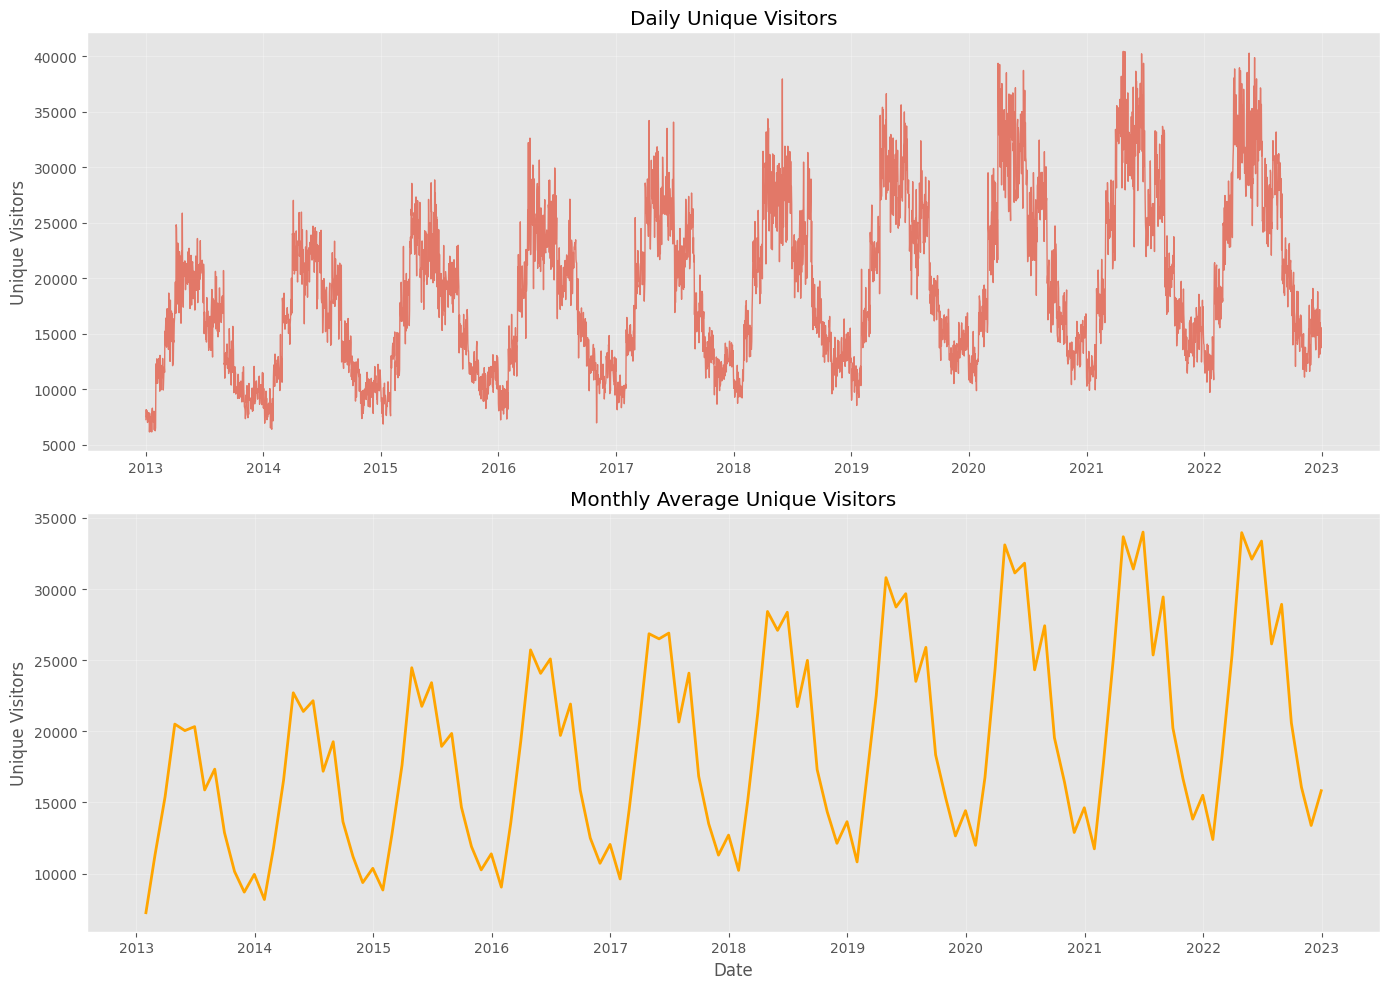

In [20]:
# Resample to monthly average
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
monthly_avg = web_traffic.set_index('date')['unique_visitors'].resample('ME').mean()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily data
axes[0].plot(web_traffic['date'], web_traffic['unique_visitors'], linewidth=1, alpha=0.7, label='Daily')
axes[0].set_title('Daily Unique Visitors')
axes[0].set_ylabel('Unique Visitors')
axes[0].grid(True, alpha=0.3)

# Monthly average
axes[1].plot(monthly_avg.index, monthly_avg.values, linewidth=2, color='orange', label='Monthly Avg')
axes[1].set_title('Monthly Average Unique Visitors')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
customers.head(10)

In [ ]:
customers['acquisition_channel'].value_counts()

In [ ]:
customers['age_group'].value_counts()

In [21]:
sales.head(10)

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
5,2012-07-09,3548386.46,2787841.68
6,2012-07-10,5234938.62,4044438.84
7,2012-07-11,5582884.78,4338313.07
8,2012-07-12,5734632.02,4458811.27
9,2012-07-13,5309511.71,4143402.78


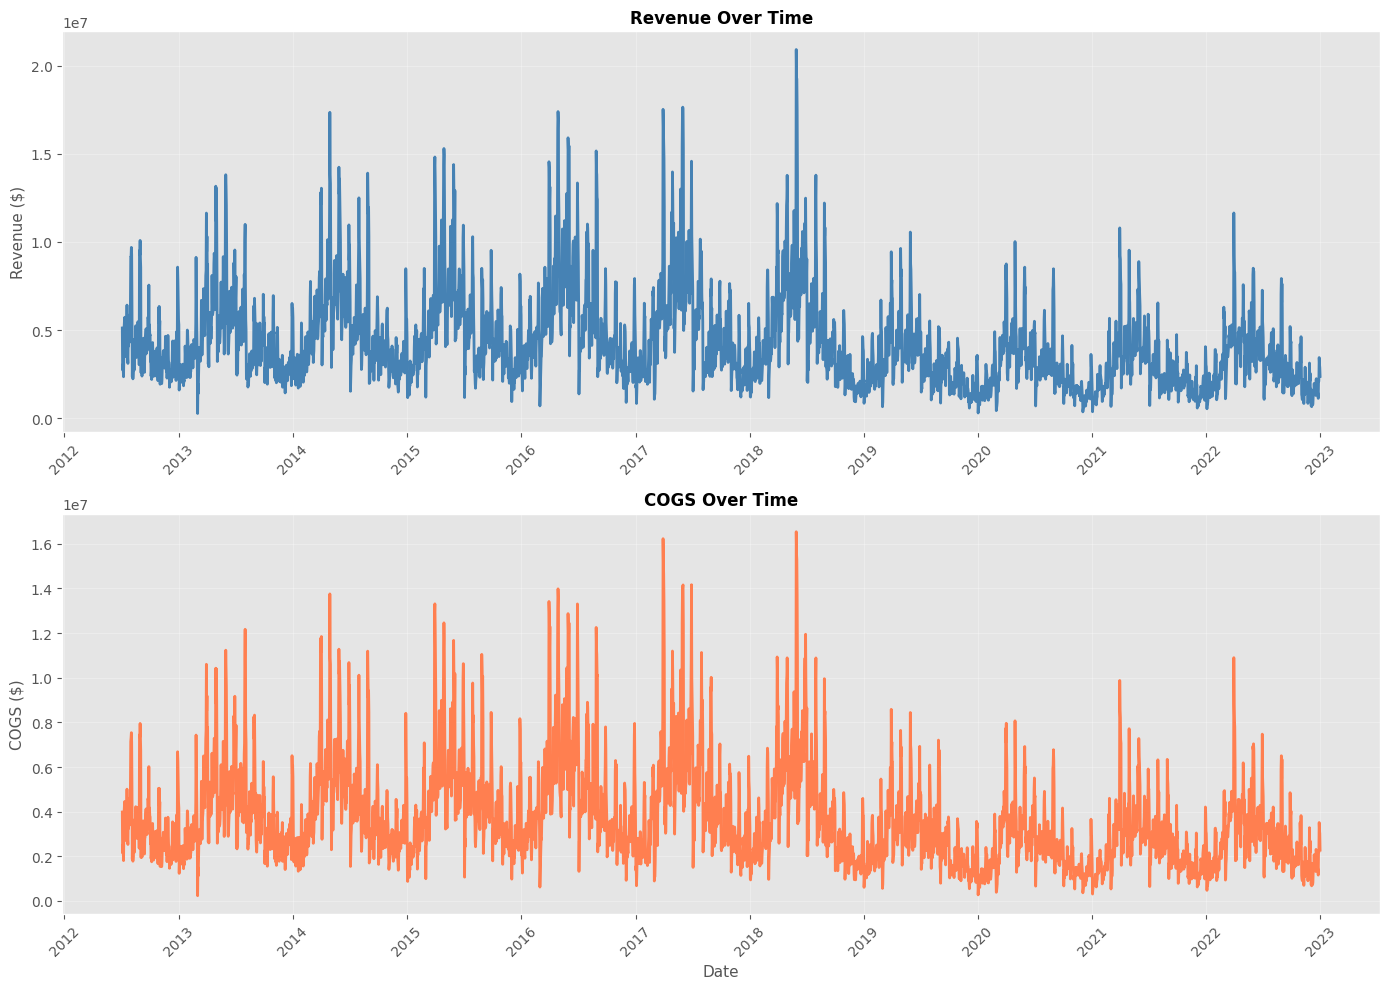

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Ensure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'])

# Revenue
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, color='steelblue')
axes[0].set_title('Revenue Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].tick_params(axis='x', rotation=45)

# COGS
axes[1].plot(sales['Date'], sales['COGS'], linewidth=2, color='coral')
axes[1].set_title('COGS Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('COGS ($)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

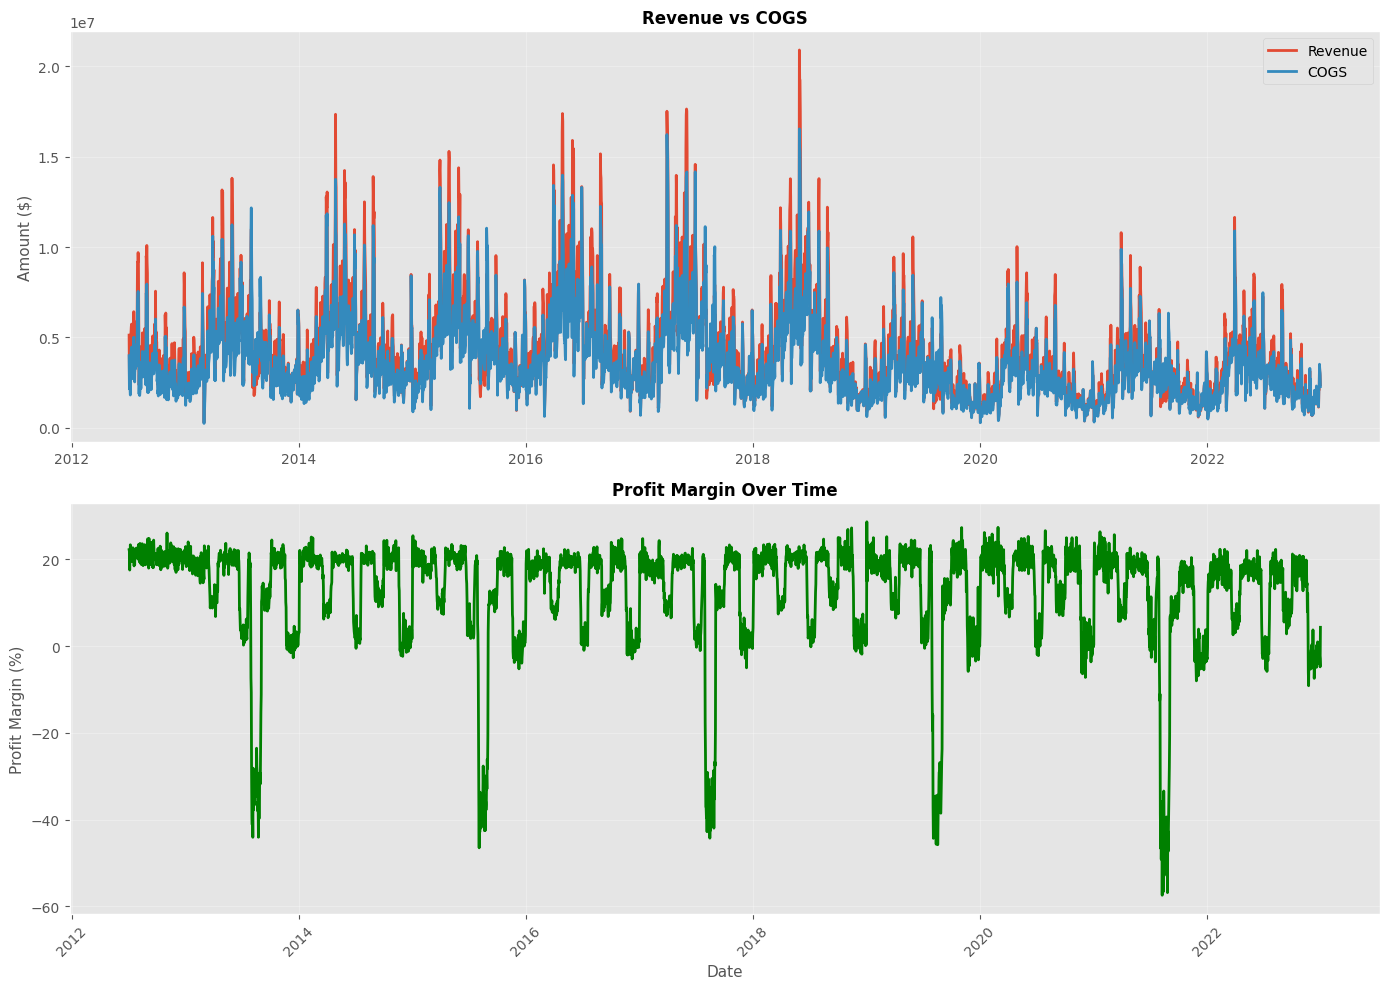

In [26]:
# Calculate profit
sales['Profit'] = sales['Revenue'] - sales['COGS']
sales['Profit_Margin'] = (sales['Profit'] / sales['Revenue'] * 100)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue and COGS
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, label='Revenue')
axes[0].plot(sales['Date'], sales['COGS'], linewidth=2, label='COGS')
axes[0].set_title('Revenue vs COGS', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount ($)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Profit Margin
axes[1].plot(sales['Date'], sales['Profit_Margin'], linewidth=2, color='green')
axes[1].set_title('Profit Margin Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Profit Margin (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

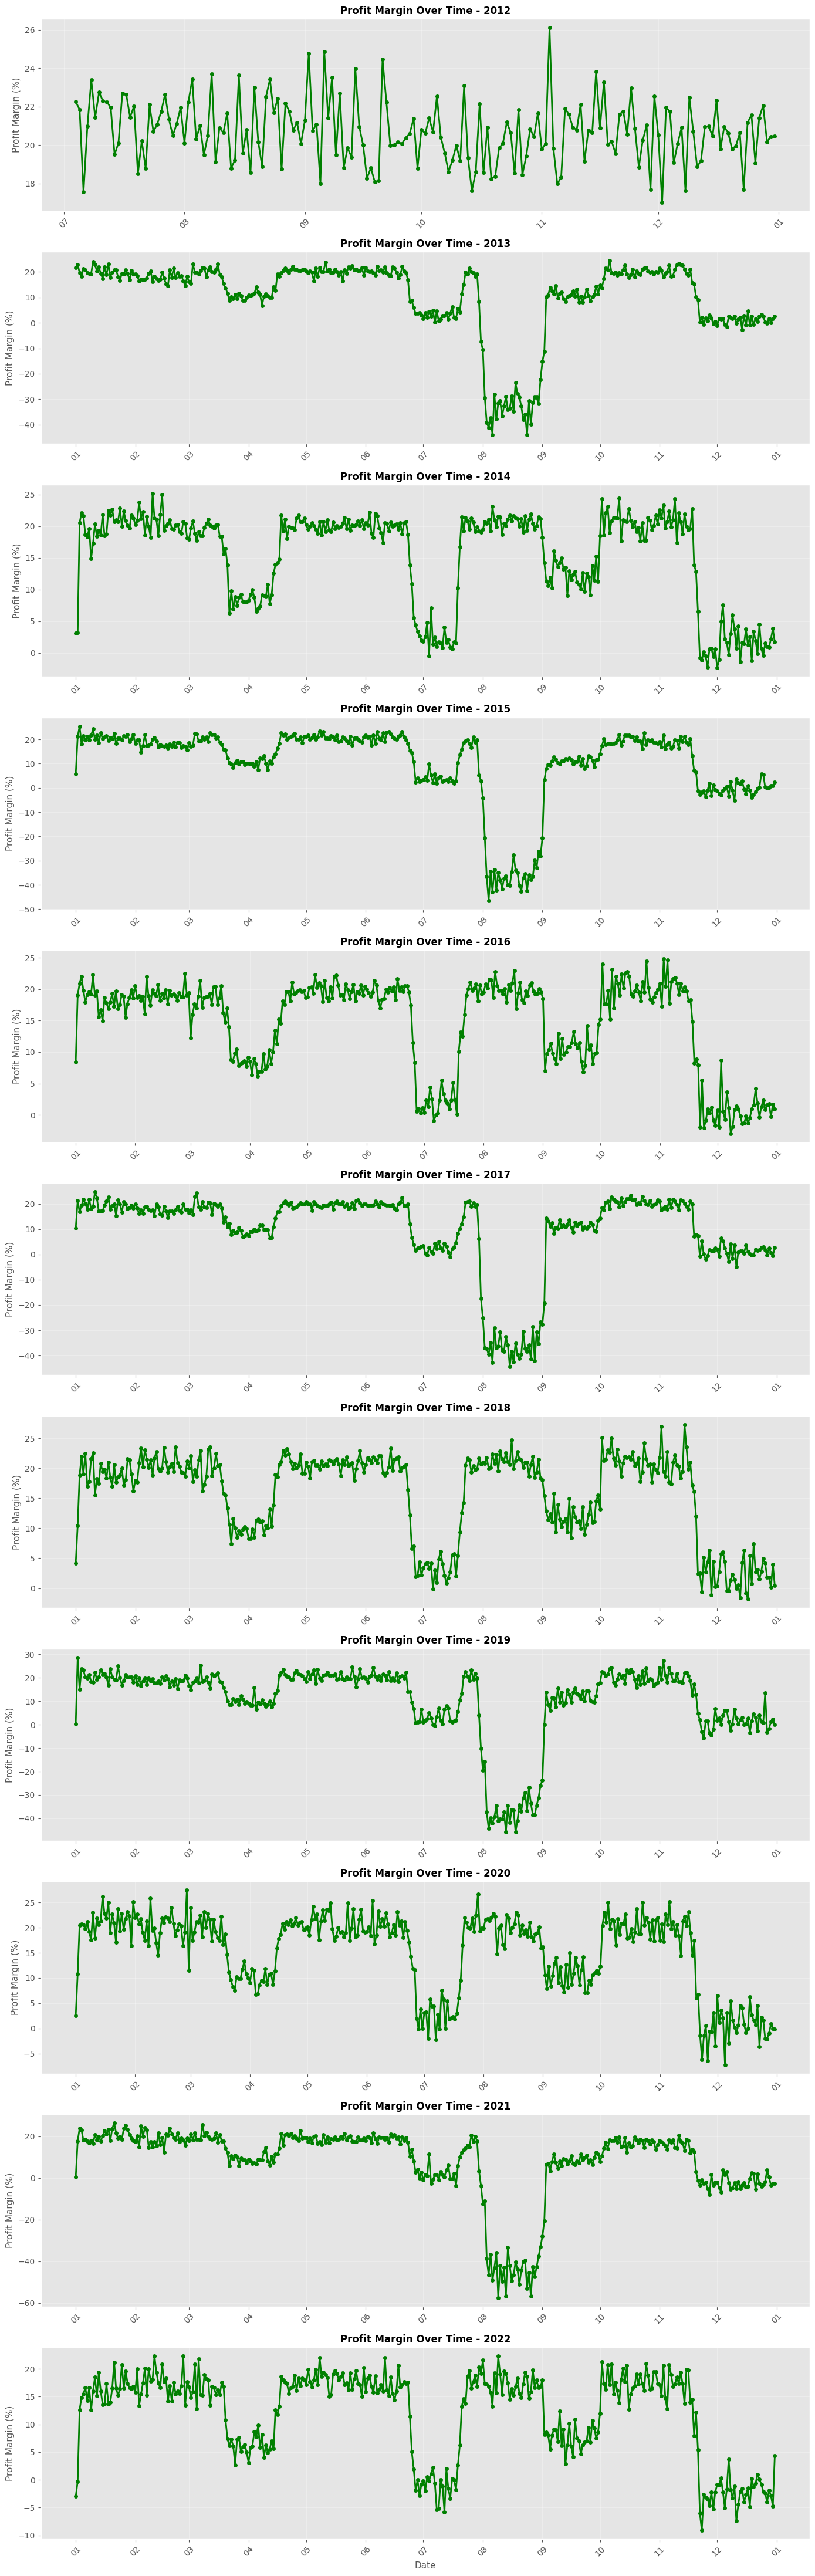

In [30]:
# Ensure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'])

# Extract year
sales['Year'] = sales['Date'].dt.year

# Get unique years and sort
years = sorted(sales['Year'].unique())

# Create subplots for each year
num_years = len(years)
fig, axes = plt.subplots(num_years, 1, figsize=(14, 4 * num_years))

# Handle case where there's only one year
if num_years == 1:
    axes = [axes]

# Plot each year
for idx, year in enumerate(years):
    year_data = sales[sales['Year'] == year]
    axes[idx].plot(year_data['Date'], year_data['Profit_Margin'], linewidth=2, color='green', marker='o', markersize=4)
    axes[idx].set_title(f'Profit Margin Over Time - {year}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Profit Margin (%)', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    
    # Format x-axis to show months
    axes[idx].xaxis.set_major_locator(mdates.MonthLocator())
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%m'))
    axes[idx].tick_params(axis='x', rotation=45)

# Set x-label only on the last subplot
axes[-1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()